11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - loss: 0.1329 - val_loss: 0.0884
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0848 - val_loss: 0.0834
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0819 - val_loss: 0.0815
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0804 - val_loss: 0.0807
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0794 - val_loss: 0.0797
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0787 - val_loss: 0.0792
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0781 - val_loss: 0.0786
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0777 - val_loss: 0.0793
Epoch 9/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0773 - val_loss: 0.0784
Epoch 10/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0770 - val_loss: 0.0776
Epoch 11/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.0767 - val_loss: 0.0775

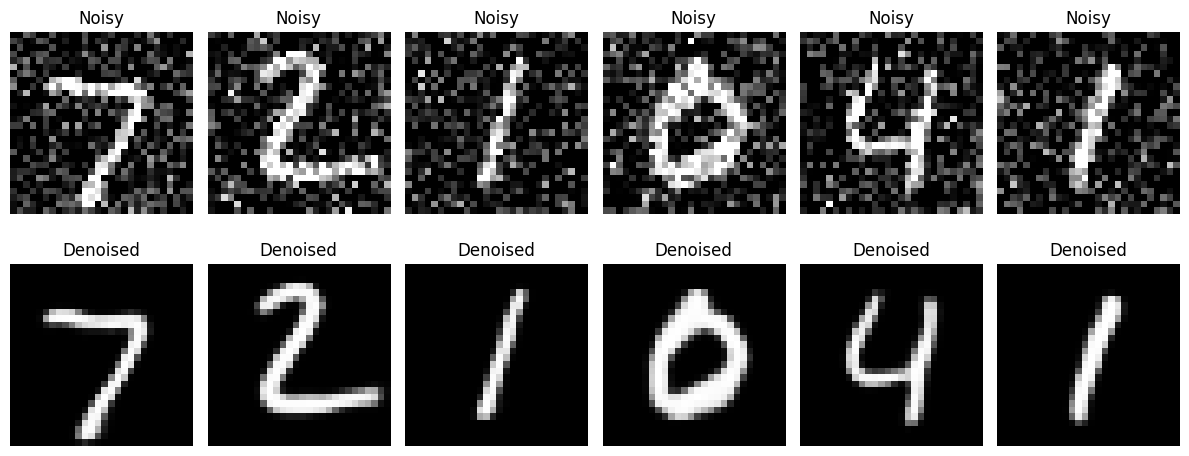

In [ ]:
# =========================================
# AUTOENCODER FOR IMAGE DENOISING (FINAL)
# =========================================

# Step 1: Import libraries
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model

# Step 2: Load dataset
(x_train, _), (x_test, _) = mnist.load_data()

# Step 3: Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Step 4: Reshape
x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

# Step 5: Add noise
noise = 0.3
x_train_noisy = x_train + noise * np.random.normal(size=x_train.shape)
x_test_noisy = x_test + noise * np.random.normal(size=x_test.shape)

x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

# Step 6: Build Autoencoder
input_img = Input(shape=(28,28,1))

# Encoder
x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = MaxPooling2D((2,2), padding='same')(x)

# Bottleneck
x = Conv2D(128, (3,3), activation='relu', padding='same')(x)

# Decoder
x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)

x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)

# Output
output = Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

model = Model(input_img, output)

# Step 7: Compile
model.compile(optimizer='adam', loss='binary_crossentropy')

# Step 8: Train
model.fit(x_train_noisy, x_train, epochs=15, batch_size=128, validation_split=0.1)

# Step 9: Predict (6 images)
num_images = 6
decoded = model.predict(x_test_noisy[:num_images])

# Step 10: Display ONLY Noisy vs Denoised
plt.figure(figsize=(12,5))

for i in range(num_images):

    # Noisy Image (Top Row)
    plt.subplot(2, num_images, i + 1)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    # Denoised Image (Bottom Row)
    plt.subplot(2, num_images, i + 1 + num_images)
    plt.imshow(decoded[i].reshape(28,28), cmap='gray')
    plt.title("Denoised")
    plt.axis('off')

plt.tight_layout()
plt.show()